In [11]:
!pip install --upgrade pip

In [12]:
pip install matplotlib numpy seaborn

Note: you may need to restart the kernel to use updated packages.


In [13]:
pip install pandas

Note: you may need to restart the kernel to use updated packages.


In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

## 1.1 Chargement des données

- Importer les bibliothèques Python nécessaires
- Charger le fichier T1.csv dans un DataFrame nommé df_wind
- **➤ Quelle colonne utiliser comme index ?** La colonne **Date/Time** car elle représente une série temporelle avec un pas de 10 minutes. L'utiliser comme index permet d'exploiter les fonctionnalités de Pandas pour les séries temporelles (resample, etc.).

In [15]:
# Chargement des données avec Date/Time comme index
df_wind = pd.read_csv("../dataset/T1.csv", parse_dates=["Date/Time"], index_col="Date/Time", dayfirst=True)
df_wind.head()

,LV ActivePower (kW),Wind Speed (m/s),Theoretical_Power_Curve (KWh),Wind Direction (°)
Date/Time,,,,
2018-01-01 00:00:00,380.047791,5.311336,416.328908,259.994904
2018-01-01 00:10:00,453.769196,5.672167,519.917511,268.641113
2018-01-01 00:20:00,306.376587,5.216037,390.900016,272.564789
2018-01-01 00:30:00,419.645905,5.659674,516.127569,271.258087
2018-01-01 00:40:00,380.650696,5.577941,491.702972,265.674286


## 1.2 Exploration des données

In [16]:
# Taille du DataFrame
print("Taille du DataFrame:", df_wind.shape)
print("Nombre de lignes:", df_wind.shape[0], "| Nombre de colonnes:", df_wind.shape[1])

Taille du DataFrame: (50530, 4)
Nombre de lignes: 50530 | Nombre de colonnes: 4


In [17]:
# 5 premières et 5 dernières lignes
print("5 premières lignes:")
display(df_wind.head())
print("5 dernières lignes:")
display(df_wind.tail())

5 premières lignes:


,LV ActivePower (kW),Wind Speed (m/s),Theoretical_Power_Curve (KWh),Wind Direction (°)
Date/Time,,,,
2018-01-01 00:00:00,380.047791,5.311336,416.328908,259.994904
2018-01-01 00:10:00,453.769196,5.672167,519.917511,268.641113
2018-01-01 00:20:00,306.376587,5.216037,390.900016,272.564789
2018-01-01 00:30:00,419.645905,5.659674,516.127569,271.258087
2018-01-01 00:40:00,380.650696,5.577941,491.702972,265.674286


5 dernières lignes:


,LV ActivePower (kW),Wind Speed (m/s),Theoretical_Power_Curve (KWh),Wind Direction (°)
Date/Time,,,,
2018-12-31 23:10:00,2963.980957,11.404030,3397.190793,80.502724
2018-12-31 23:20:00,1684.353027,7.332648,1173.055771,84.062599
2018-12-31 23:30:00,2201.106934,8.435358,1788.284755,84.742500
2018-12-31 23:40:00,2515.694092,9.421366,2418.382503,84.297913
2018-12-31 23:50:00,2820.466064,9.979332,2779.184096,82.274620


In [18]:
# Types de données
print(df_wind.dtypes)

LV ActivePower (kW)              float64
Wind Speed (m/s)                 float64
Theoretical_Power_Curve (KWh)    float64
Wind Direction (°)               float64
dtype: object


In [19]:
# Valeurs manquantes
print("Valeurs manquantes par colonne:")
print(df_wind.isna().sum())

Valeurs manquantes par colonne:
LV ActivePower (kW)              0
Wind Speed (m/s)                 0
Theoretical_Power_Curve (KWh)    0
Wind Direction (°)               0
dtype: int64


In [22]:
# Colonne Wind Speed en NumPy
wind_speed_col = [c for c in df_wind.columns if "wind speed" in c.lower()][0]
wind_speed_np = df_wind[wind_speed_col].values
print("Type:", type(wind_speed_np))
print("Shape:", wind_speed_np.shape)

Type: <class 'numpy.ndarray'>
Shape: (50530,)


In [23]:
# Moyenne et écart-type de la vitesse du vent
mean_ws = df_wind[wind_speed_col].mean()
std_ws = df_wind[wind_speed_col].std()
print(f"Moyenne Wind Speed: {mean_ws:.4f} m/s")
print(f"Écart-type Wind Speed: {std_ws:.4f} m/s")

Moyenne Wind Speed: 7.5580 m/s
Écart-type Wind Speed: 4.2272 m/s


## 1.3 Manipulation des données

### Renommage des colonnes

In [24]:
# Mapping des noms de colonnes (le fichier T1.csv a des noms légèrement différents)
rename_map = {
    "LV ActivePower (kW)": "Power",
    "LV Active Power (kW)": "Power",
    "Wind Speed (m/s)": "Wind speed",
    "Theoretical_Power_Curve (KWh)": "Theoretical power",
    "Theoretical Power (kWh)": "Theoretical power",
    "Wind Direction (°)": "Wind direction"
}
df_wind = df_wind.rename(columns={k: v for k, v in rename_map.items() if k in df_wind.columns})
df_wind.head()

,Power,Wind speed,Theoretical power,Wind direction
Date/Time,,,,
2018-01-01 00:00:00,380.047791,5.311336,416.328908,259.994904
2018-01-01 00:10:00,453.769196,5.672167,519.917511,268.641113
2018-01-01 00:20:00,306.376587,5.216037,390.900016,272.564789
2018-01-01 00:30:00,419.645905,5.659674,516.127569,271.258087
2018-01-01 00:40:00,380.650696,5.577941,491.702972,265.674286


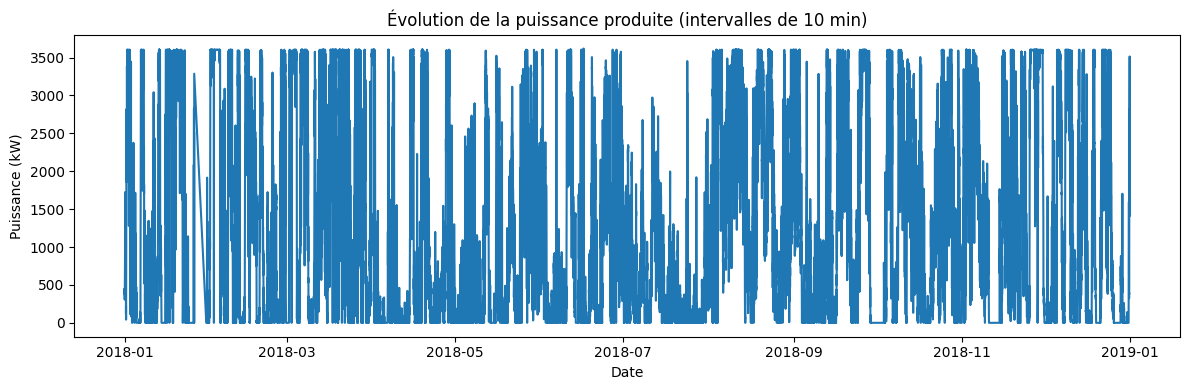

In [45]:
# Évolution de la puissance produite en fonction du temps
plt.figure(figsize=(12, 4))
plt.plot(df_wind.index, df_wind["Power"])
plt.xlabel("Date")
plt.ylabel("Puissance (kW)")
plt.title("Évolution de la puissance produite (intervalles de 10 min)")
plt.tight_layout()
plt.show()

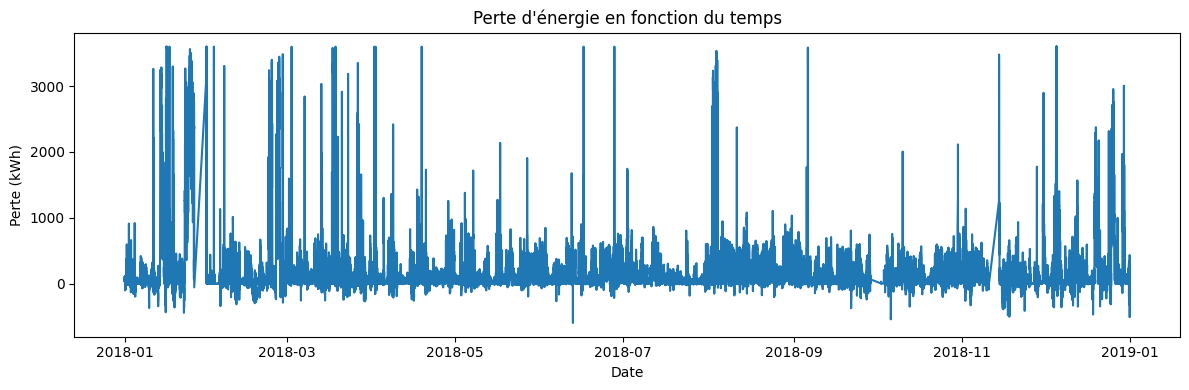

In [26]:
# Colonne loss = puissance théorique - puissance réelle
df_wind["loss"] = df_wind["Theoretical power"] - df_wind["Power"]

plt.figure(figsize=(12, 4))
plt.plot(df_wind.index, df_wind["loss"])
plt.xlabel("Date")
plt.ylabel("Perte (kWh)")
plt.title("Perte d'énergie en fonction du temps")
plt.tight_layout()
plt.show()

In [27]:
# Identification des périodes de maintenance (vent > 3.3 m/s et puissance <= 0)
maintenance_mask = (df_wind["Wind speed"] > 3.3) & (df_wind["Power"] <= 0)
maintenance_count = maintenance_mask.sum()
print(f"Nombre de lignes en maintenance: {maintenance_count}")

# DataFrame sans maintenance
df_wind_nm = df_wind[~maintenance_mask].copy()
print(f"Taille df_wind_nm: {df_wind_nm.shape}")

Nombre de lignes en maintenance: 2629
Taille df_wind_nm: (47901, 5)


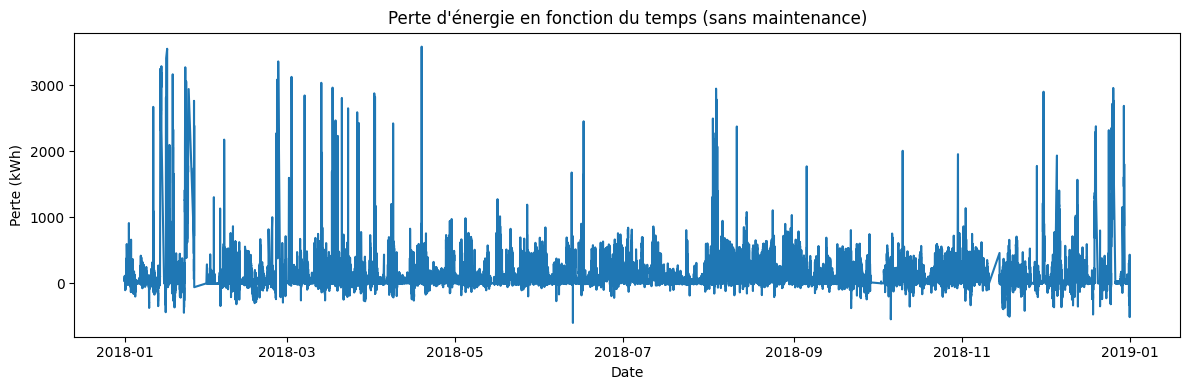

In [28]:
# Perte d'énergie en fonction du temps (sans maintenance)
plt.figure(figsize=(12, 4))
plt.plot(df_wind_nm.index, df_wind_nm["loss"])
plt.xlabel("Date")
plt.ylabel("Perte (kWh)")
plt.title("Perte d'énergie en fonction du temps (sans maintenance)")
plt.tight_layout()
plt.show()

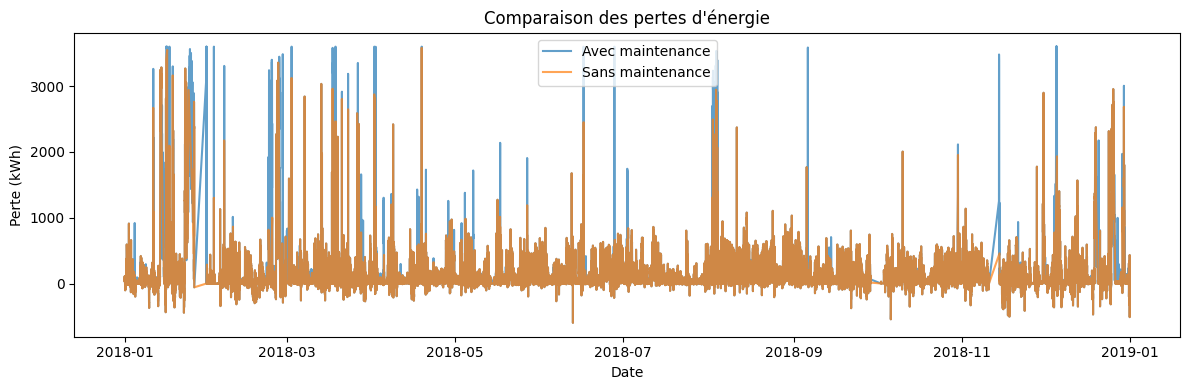

In [29]:
# Comparaison des pertes : avec maintenance vs sans maintenance
plt.figure(figsize=(12, 4))
plt.plot(df_wind.index, df_wind["loss"], label="Avec maintenance", alpha=0.7)
plt.plot(df_wind_nm.index, df_wind_nm["loss"], label="Sans maintenance", alpha=0.7)
plt.xlabel("Date")
plt.ylabel("Perte (kWh)")
plt.title("Comparaison des pertes d'énergie")
plt.legend()
plt.tight_layout()
plt.show()

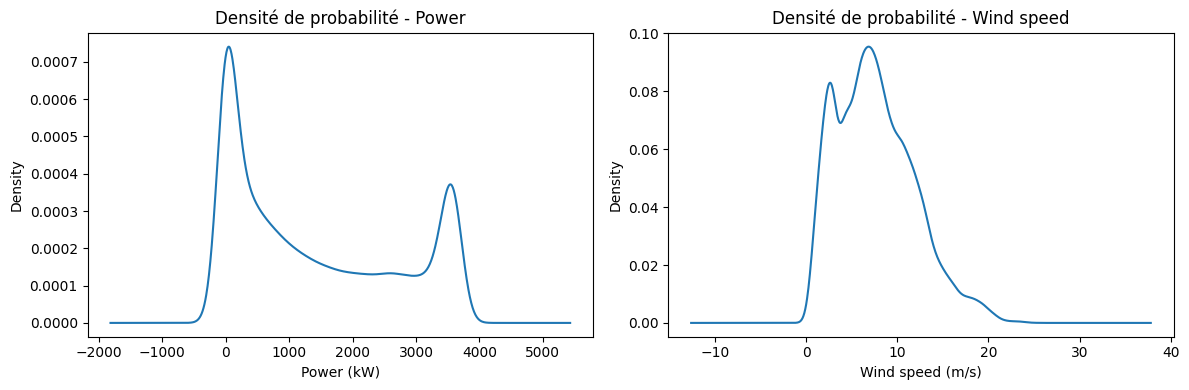

In [30]:
# KDE de la puissance et de la vitesse du vent
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df_wind_nm["Power"].plot(kind="kde", ax=axes[0])
axes[0].set_title("Densité de probabilité - Power")
axes[0].set_xlabel("Power (kW)")
df_wind_nm["Wind speed"].plot(kind="kde", ax=axes[1])
axes[1].set_title("Densité de probabilité - Wind speed")
axes[1].set_xlabel("Wind speed (m/s)")
plt.tight_layout()
plt.show()

### Composantes x et y du vent

Formules : x = Ws × sin(Wd × π/180), y = Ws × cos(Wd × π/180)

In [31]:
# Composantes x et y du vent
Ws = df_wind_nm["Wind speed"].values
Wd = df_wind_nm["Wind direction"].values
df_wind_nm["x"] = Ws * np.sin(np.radians(Wd))
df_wind_nm["y"] = Ws * np.cos(np.radians(Wd))
df_wind_nm[["Wind speed", "Wind direction", "x", "y"]].head()

,Wind speed,Wind direction,x,y
Date/Time,,,,
2018-01-01 00:00:00,5.311336,259.994904,-5.230563,-0.922769
2018-01-01 00:10:00,5.672167,268.641113,-5.670572,-0.134514
2018-01-01 00:20:00,5.216037,272.564789,-5.210812,0.233413
2018-01-01 00:30:00,5.659674,271.258087,-5.658310,0.124264
2018-01-01 00:40:00,5.577941,265.674286,-5.562052,-0.420723


### Rééchantillonnage (resample)

In [32]:
# DataFrames horaire, journalier, hebdomadaire, mensuel
df_hourly = df_wind_nm.resample("h").mean()
df_daily = df_wind_nm.resample("d").mean()
df_weekly = df_wind_nm.resample("W").mean()
df_monthly = df_wind_nm.resample("ME").mean()

print("Horaire:", df_hourly.shape, "| Journalier:", df_daily.shape)
print("Hebdomadaire:", df_weekly.shape, "| Mensuel:", df_monthly.shape)

Horaire: (8760, 7) | Journalier: (365, 7)
Hebdomadaire: (53, 7) | Mensuel: (12, 7)


C:\Users\maxou\AppData\Local\Temp\ipykernel_21732\1613180372.py:3: Pandas4Warning: 'd' is deprecated and will be removed in a future version, please use 'D' instead.
  df_daily = df_wind_nm.resample("d").mean()


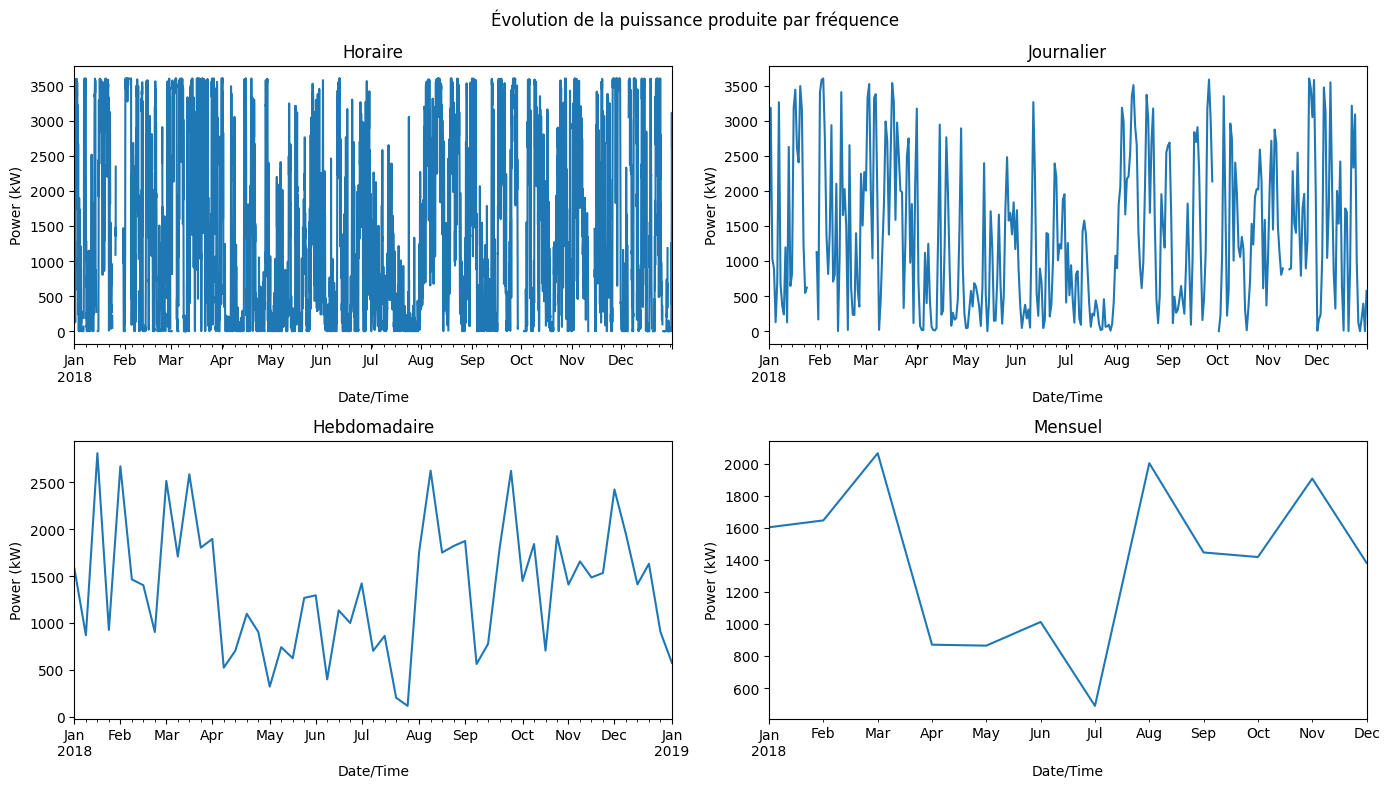

In [33]:
# Évolution de la puissance pour chaque fréquence (subplots)
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

df_hourly["Power"].plot(ax=axes[0, 0], title="Horaire")
df_daily["Power"].plot(ax=axes[0, 1], title="Journalier")
df_weekly["Power"].plot(ax=axes[1, 0], title="Hebdomadaire")
df_monthly["Power"].plot(ax=axes[1, 1], title="Mensuel")

for ax in axes.ravel():
    ax.set_ylabel("Power (kW)")
plt.suptitle("Évolution de la puissance produite par fréquence")
plt.tight_layout()
plt.show()

**Différence resample() vs asfreq() :**
- **resample()** : agrège les données (moyenne, somme, etc.) sur chaque période
- **asfreq()** : réorganise l'index à une nouvelle fréquence sans agrégation ; garde la dernière valeur ou crée des NaN

In [34]:
# Interpolation des NaN
df_hourly = df_hourly.interpolate()
df_daily = df_daily.interpolate()
df_weekly = df_weekly.interpolate()
df_monthly = df_monthly.interpolate()
print("NaN après interpolation:", df_hourly.isna().sum().sum())

NaN après interpolation: 0


In [35]:
# Fonction direction : catégorise la vitesse du vent
def direction(wind_speed):
    if wind_speed < 5:
        return "faible"
    elif wind_speed < 10:
        return "modéré"
    else:
        return "fort"

df_daily["Direction"] = df_daily["Wind speed"].apply(direction)
df_weekly["Direction"] = df_weekly["Wind speed"].apply(direction)
df_monthly["Direction"] = df_monthly["Wind speed"].apply(direction)
df_daily[["Wind speed", "Direction"]].head(10)

,Wind speed,Direction
Date/Time,,
2018-01-01,8.022975,modéré
2018-01-02,12.000548,fort
2018-01-03,6.689973,modéré
2018-01-04,6.338899,modéré
2018-01-05,3.106688,faible
2018-01-06,4.103764,faible
2018-01-07,12.193147,fort
2018-01-08,5.767732,modéré
2018-01-09,4.760865,faible


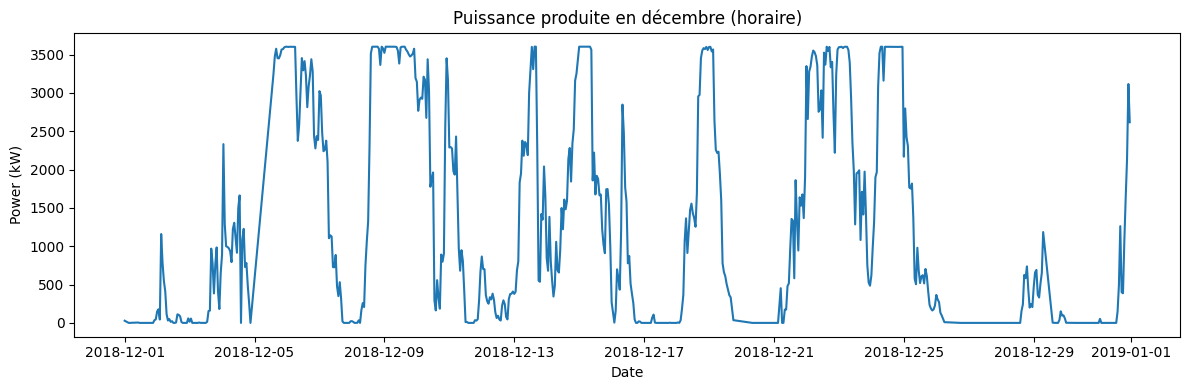

In [36]:
# Puissance horaire en décembre
dec_hourly = df_hourly[df_hourly.index.month == 12]
plt.figure(figsize=(12, 4))
plt.plot(dec_hourly.index, dec_hourly["Power"])
plt.xlabel("Date")
plt.ylabel("Power (kW)")
plt.title("Puissance produite en décembre (horaire)")
plt.tight_layout()
plt.show()

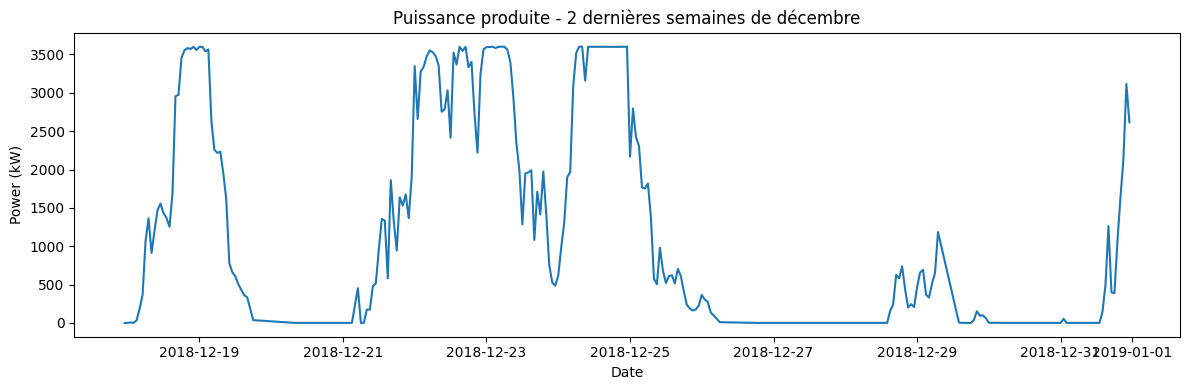

In [37]:
# Deux dernières semaines de décembre
dec_hourly = df_hourly[(df_hourly.index.month == 12) & (df_hourly.index.year == 2018)]
last_two_weeks = dec_hourly[dec_hourly.index >= dec_hourly.index.max() - pd.Timedelta(days=14)]
plt.figure(figsize=(12, 4))
plt.plot(last_two_weeks.index, last_two_weeks["Power"])
plt.xlabel("Date")
plt.ylabel("Power (kW)")
plt.title("Puissance produite - 2 dernières semaines de décembre")
plt.tight_layout()
plt.show()

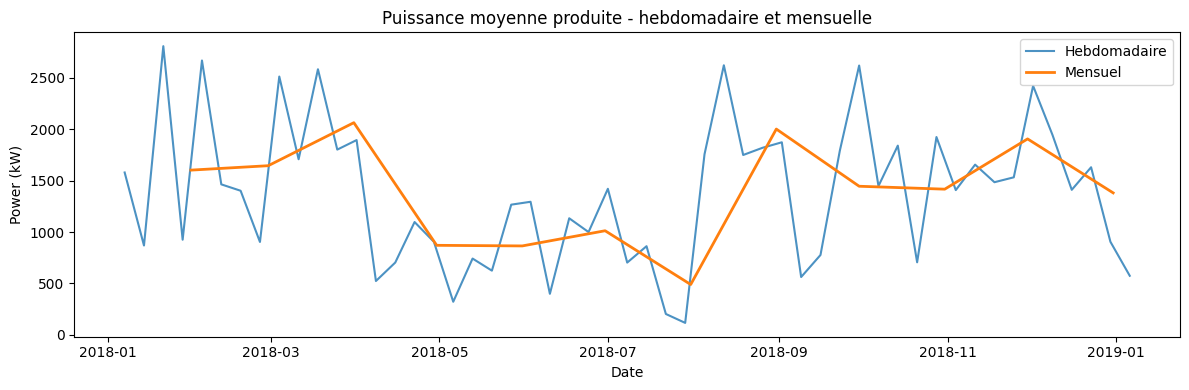

In [38]:
# Puissance moyenne hebdomadaire et mensuelle sur un même graphique
plt.figure(figsize=(12, 4))
plt.plot(df_weekly.index, df_weekly["Power"], label="Hebdomadaire", alpha=0.8)
plt.plot(df_monthly.index, df_monthly["Power"], label="Mensuel", linewidth=2)
plt.xlabel("Date")
plt.ylabel("Power (kW)")
plt.title("Puissance moyenne produite - hebdomadaire et mensuelle")
plt.legend()
plt.tight_layout()
plt.show()

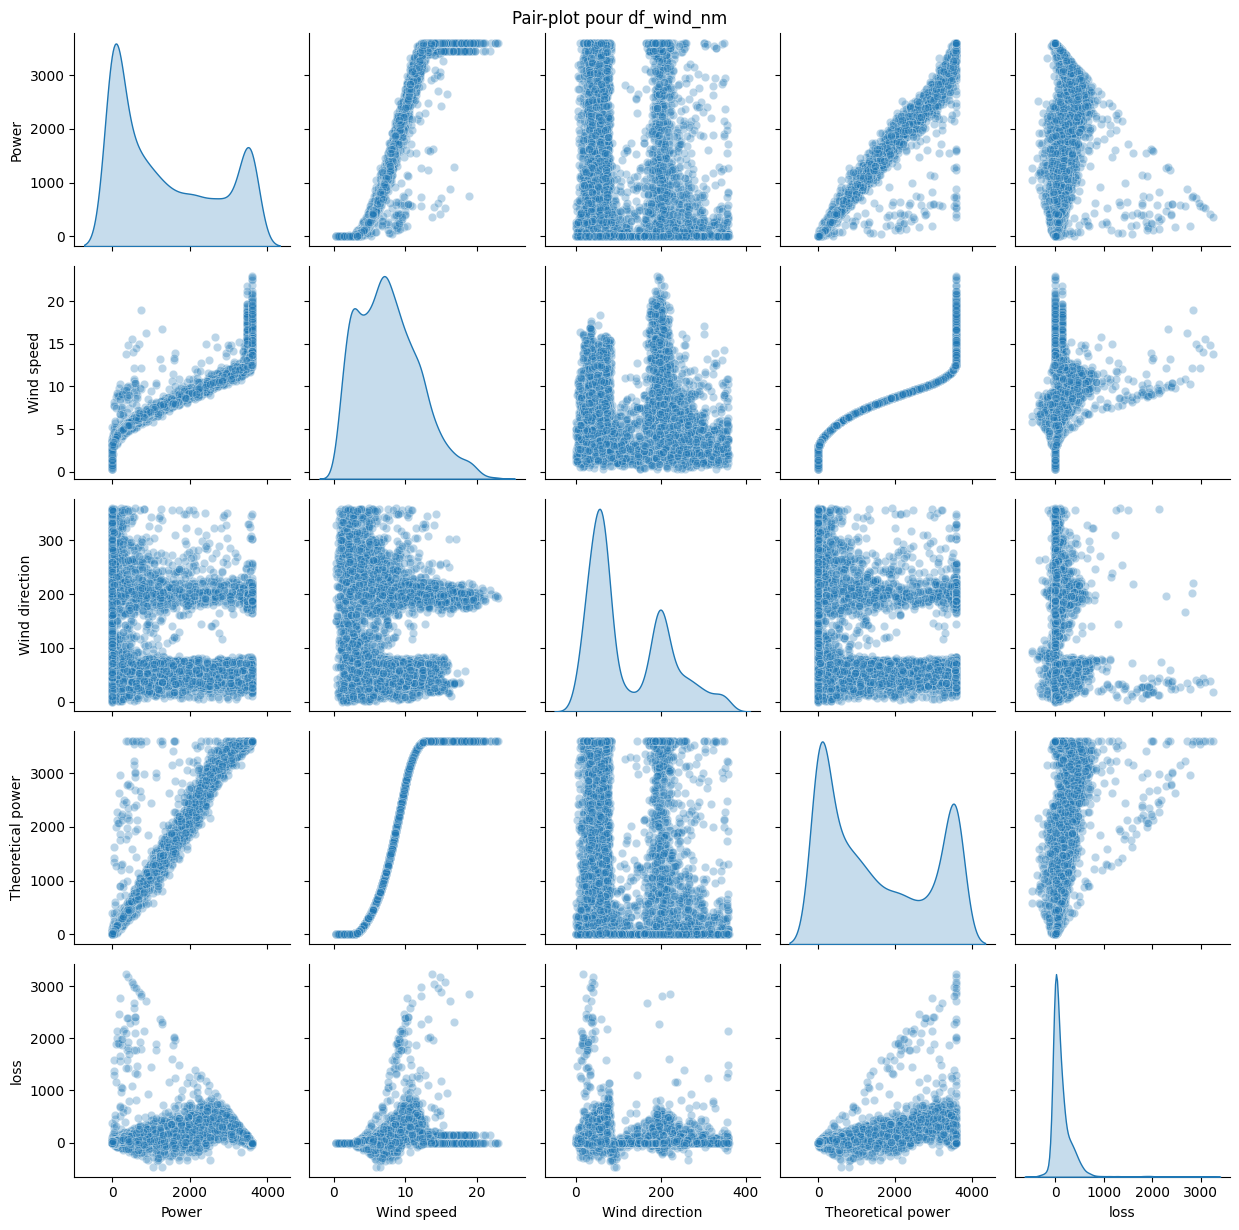

In [39]:
# Pair-plot pour le DataFrame filtré (df_wind_nm) - échantillon pour lisibilité
cols_viz = ["Power", "Wind speed", "Wind direction", "Theoretical power", "loss"]
sample = df_wind_nm[cols_viz].dropna().sample(min(5000, len(df_wind_nm)), random_state=42)
sns.pairplot(sample, diag_kind="kde", plot_kws={"alpha": 0.3})
plt.suptitle("Pair-plot pour df_wind_nm")
plt.tight_layout()
plt.show()

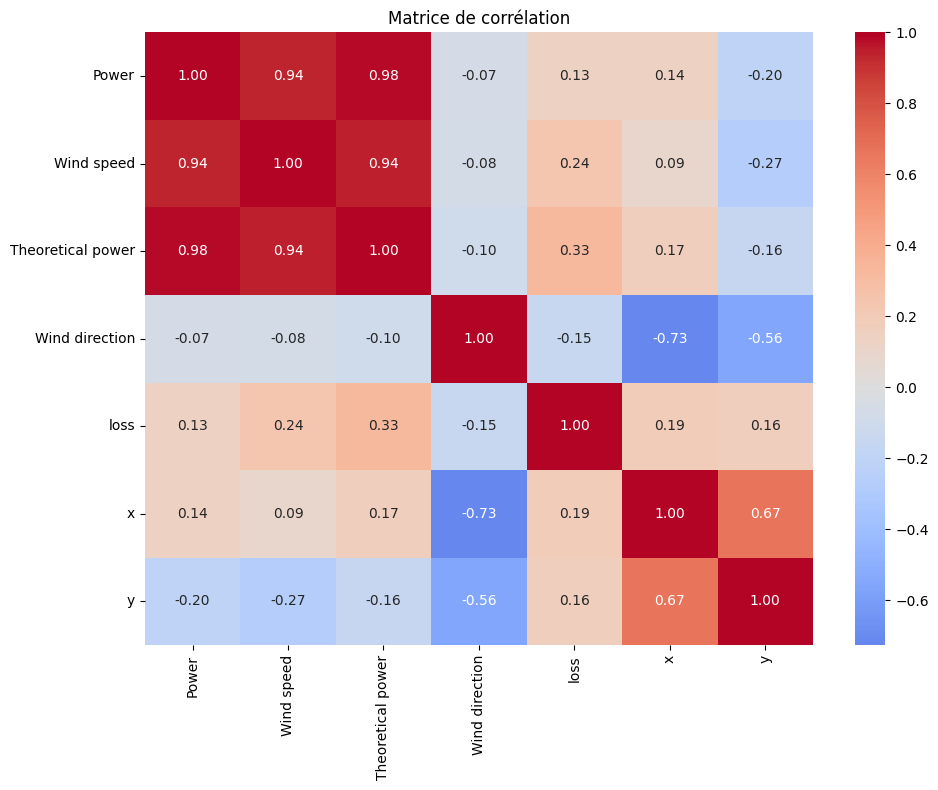

In [40]:
# Carte de chaleur des corrélations
numeriques = df_wind_nm.select_dtypes(include=[np.number])
corr = numeriques.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Matrice de corrélation")
plt.tight_layout()
plt.show()

In [41]:
# Corrélations avec Power
power_corr = corr["Power"].drop("Power").sort_values(ascending=False)
print("Variables corrélées avec Power (ordre décroissant):")
print(power_corr)
print("\n★ Variables avec corrélation forte:", list(power_corr[abs(power_corr) > 0.5].index))
print("★ Variables sans corrélation significative:", list(power_corr[abs(power_corr) < 0.2].index))

Variables corrélées avec Power (ordre décroissant):
Theoretical power    0.980149
Wind speed           0.937837
x                    0.137046
loss                 0.131564
Wind direction      -0.071778
y                   -0.200465
Name: Power, dtype: float64

★ Variables avec corrélation forte: ['Theoretical power', 'Wind speed']
★ Variables sans corrélation significative: ['x', 'loss', 'Wind direction']


In [46]:
corr_kendall = numeriques.corr(method="kendall")
corr_spearman = numeriques.corr(method="spearman")
print("Corrélations avec Power - Kendall:")
print(corr_kendall["Power"].drop("Power").sort_values(ascending=False))
print("\nCorrélations avec Power - Spearman:")
print(corr_spearman["Power"].drop("Power").sort_values(ascending=False))
print("\n★ Conclusion: Les classements de corrélation restent similaires.")

Corrélations avec Power - Kendall:
Theoretical power    0.930373
Wind speed           0.915832
loss                 0.247383
x                    0.194414
y                    0.084068
Wind direction      -0.058194
Name: Power, dtype: float64

Corrélations avec Power - Spearman:
Theoretical power    0.984369
Wind speed           0.982551
loss                 0.311909
x                    0.198862
y                    0.093384
Wind direction      -0.091761
Name: Power, dtype: float64

★ Conclusion: Les classements de corrélation restent similaires.


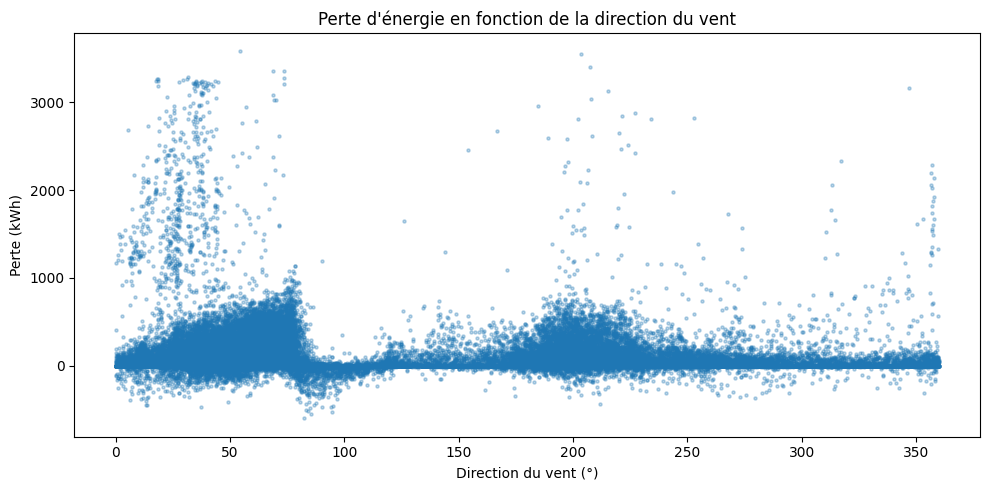

In [43]:
# Perte d'énergie en fonction de la direction du vent
plt.figure(figsize=(10, 5))
plt.scatter(df_wind_nm["Wind direction"], df_wind_nm["loss"], alpha=0.3, s=5)
plt.xlabel("Direction du vent (°)")
plt.ylabel("Perte (kWh)")
plt.title("Perte d'énergie en fonction de la direction du vent")
plt.tight_layout()
plt.show()

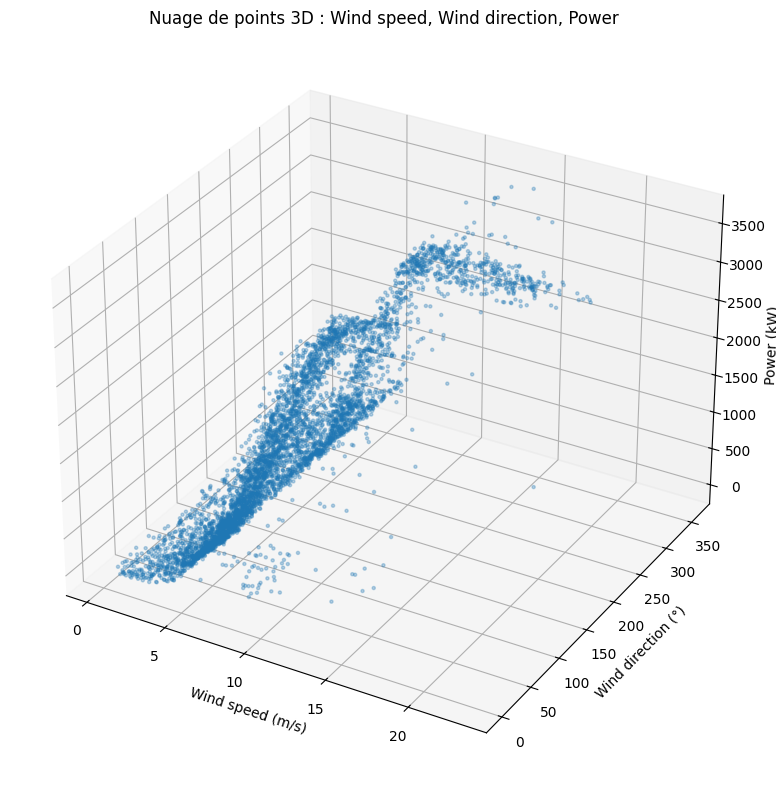

In [44]:
# Nuage de points 3D : Wind speed (x), Wind direction (y), Power (z)
sample = df_wind_nm.sample(min(5000, len(df_wind_nm)), random_state=42)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(sample["Wind speed"], sample["Wind direction"], sample["Power"], alpha=0.3, s=5)
ax.set_xlabel("Wind speed (m/s)")
ax.set_ylabel("Wind direction (°)")
ax.set_zlabel("Power (kW)")
ax.set_title("Nuage de points 3D : Wind speed, Wind direction, Power")
plt.tight_layout()
plt.show()